# Notebook 05 -- Clinical Validation: TLS Functional Score

**Input**:  
- `tls_predictions.csv`   -- per-TLS GNN scores (from nb04)  
- `tls_cluster_labels.csv` -- per-TLS handcrafted scores (from nb03)  
- `rcc_visium_labeled.h5ad` -- AnnData with clinical metadata  

**Analyses**:  
1. Patient-level score aggregation and visualisation  
2. GNN score vs. handcrafted markers (added value over composite score)  
3. TLS heterogeneity within patients  
4. Clinical correlations (tissue type, grade, etc.)  
5. Kaplan-Meier curves (survival stratification)  
6. ICB response prediction  
7. Summary

In [1]:
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

# lifelines for Kaplan-Meier
try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    HAS_LIFELINES = True
    print('lifelines: OK')
except ImportError:
    HAS_LIFELINES = False
    print('lifelines not available -- install with: pip install lifelines')

# scanpy for adata
try:
    import scanpy as sc
    HAS_SCANPY = True
    print('scanpy: OK')
except ImportError:
    HAS_SCANPY = False
    print('scanpy not available')

print('Setup complete')


lifelines: OK
scanpy: OK
Setup complete


## 1. Load Predictions and Cluster Labels

In [2]:
CLUSTER_DATA = PROJECT_ROOT / 'data'
CKPT_DIR     = PROJECT_ROOT / 'checkpoints'
OUT_DIR      = CKPT_DIR   # save all outputs here

# Load GNN predictions (from nb04)
pred_csv  = CLUSTER_DATA / 'processed' / 'tls_predictions.csv'
label_csv = PROJECT_ROOT / 'data' / 'processed' / 'tls_cluster_labels.csv'
adata_h5  = CLUSTER_DATA / 'processed' / 'rcc_visium_labeled.h5ad'

pred_df  = pd.read_csv(pred_csv)
label_df = pd.read_csv(label_csv)

print(f'Predictions: {len(pred_df)} TLS regions, {pred_df["sample_id"].nunique()} samples')
print(f'Columns: {list(pred_df.columns)}')
print(f'\nCluster labels: {len(label_df)} rows')
print(f'Columns: {list(label_df.columns)}')

# Merge on cluster_id + sample_id
merged = pred_df.merge(
    label_df[['cluster_id', 'sample_id', 'n_spots',
               'plasma_mean', 'tregs_mean', 'chemo_mean',
               'myl_sup_mean', 'composite_mean']],
    on=['cluster_id', 'sample_id'], how='left'
)
print(f'\nMerged: {len(merged)} rows, {merged["composite_mean"].isna().sum()} missing composite')
merged.head(3)


Predictions: 915 TLS regions, 16 samples
Columns: ['cluster_id', 'sample_id', 'split', 'label_name', 'y_true', 'p_immunogenic', 'p_tolerogenic', 'tls_functional_score', 'pred_label', 'umap1', 'umap2']

Cluster labels: 915 rows
Columns: ['cluster_id', 'sample_id', 'n_spots', 'label', 'label_name', 'plasma_mean', 'tregs_mean', 'chemo_mean', 'myl_sup_mean', 'composite_mean']

Merged: 915 rows, 0 missing composite


,cluster_id,sample_id,split,label_name,y_true,p_immunogenic,p_tolerogenic,tls_functional_score,pred_label,umap1,umap2,n_spots,plasma_mean,tregs_mean,chemo_mean,myl_sup_mean,composite_mean
0,13,GSM5924030_ffpe_c_2,train,immunogenic,0,0.933669,6.633146e-02,6.633146e-02,0,0.064020,1.859205,12,1.956586,0.006490,0.371155,0.163866,0.297068
1,21,GSM5924030_ffpe_c_2,train,immunogenic,0,1.000000,3.161872e-09,3.161872e-09,0,-13.431157,-20.029406,244,1.328905,0.081109,0.629298,0.259539,0.302106
2,27,GSM5924030_ffpe_c_2,train,immunogenic,0,0.995612,4.388245e-03,4.388245e-03,0,-10.144087,-17.150257,18,1.521848,0.081050,0.185549,0.195105,0.248470


In [3]:

# ── Bootstrap: write clinical_metadata.csv to cluster data dir if missing ────
# Data sourced from:
#   mmc2.xlsx (Table S1, Meylan 2022) -> tumor_stage
#   mmc4.xlsx (Table S3, Meylan 2022) -> pct_igg_tumor, pct_iga_tumor, cleaved_casp3_mm2
#   Cohort A/B = surgery only; Cohort C = BIONIKK ICI trial

_CLIN_DATA = [
    # sample_id, patient_id, cohort, tissue_prep, treatment, tumor_stage, pct_igg_tumor, pct_iga_tumor, cleaved_casp3_mm2
    ('GSM5924030_ffpe_c_2',   'c_2',  'C', 'FFPE',   'BIONIKK_ICI',  'pT1a', 80.0,  0.0,  128.400448),
    ('GSM5924031_ffpe_c_3',   'c_3',  'C', 'FFPE',   'BIONIKK_ICI',  'pT4',  65.0,  5.0,  None),
    ('GSM5924032_ffpe_c_4',   'c_4',  'C', 'FFPE',   'BIONIKK_ICI',  'pT3a', None,  None, None),
    ('GSM5924033_ffpe_c_7',   'c_7',  'C', 'FFPE',   'BIONIKK_ICI',  'pT3b', 80.0,  2.0,  None),
    ('GSM5924034_ffpe_c_10',  'c_10', 'C', 'FFPE',   'BIONIKK_ICI',  'pT3a', 90.0,  10.0, None),
    ('GSM5924035_ffpe_c_20',  'c_20', 'C', 'FFPE',   'BIONIKK_ICI',  'pT1b', 85.0,  5.0,  None),
    ('GSM5924036_ffpe_c_21',  'c_21', 'C', 'FFPE',   'BIONIKK_ICI',  None,   30.0,  2.0,  None),
    ('GSM5924037_ffpe_c_34',  'c_34', 'C', 'FFPE',   'BIONIKK_ICI',  'pT3a', 80.0,  20.0, None),
    ('GSM5924038_ffpe_c_36',  'c_36', 'C', 'FFPE',   'BIONIKK_ICI',  'pT3a', 30.0,  1.0,  None),
    ('GSM5924039_ffpe_c_39',  'c_39', 'C', 'FFPE',   'BIONIKK_ICI',  'pT3a', 95.0,  30.0, None),
    ('GSM5924040_ffpe_c_45',  'c_45', 'C', 'FFPE',   'BIONIKK_ICI',  'pT3a', 70.0,  10.0, None),
    ('GSM5924041_ffpe_c_51',  'c_51', 'C', 'FFPE',   'BIONIKK_ICI',  'pT3a', 80.0,  30.0, None),
    ('GSM5924042_frozen_a_1', 'a_1',  'A', 'frozen', 'surgery_only', 'pT1b', 40.0,  5.0,  None),
    ('GSM5924043_frozen_a_3', 'a_3',  'A', 'frozen', 'surgery_only', 'pT3c', 1.0,   0.0,  None),
    ('GSM5924044_frozen_a_15','a_15', 'A', 'frozen', 'surgery_only', 'pT1b', 30.0,  0.0,  None),
    ('GSM5924045_frozen_a_17','a_17', 'A', 'frozen', 'surgery_only', 'pT1b', 85.0,  0.0,  None),
    ('GSM5924046_frozen_b_1', 'b_1',  'B', 'frozen', 'surgery_only', 'pT1',  1.0,   0.0,  None),
    ('GSM5924047_frozen_b_7', 'b_7',  'B', 'frozen', 'surgery_only', 'pT3',  None,  None, None),
    ('GSM5924048_frozen_b_13','b_13', 'B', 'frozen', 'surgery_only', 'pT3',  None,  None, None),
    ('GSM5924049_frozen_b_18','b_18', 'B', 'frozen', 'surgery_only', 'pT2',  None,  None, None),
    ('GSM5924050_frozen_c_2', 'c_2',  'C', 'frozen', 'BIONIKK_ICI',  'pT1a', 80.0,  0.0,  128.400448),
    ('GSM5924051_frozen_c_5', 'c_5',  'C', 'frozen', 'BIONIKK_ICI',  'pT3a', 65.0,  0.0,  12.747760),
    ('GSM5924052_frozen_c_23','c_23', 'C', 'frozen', 'BIONIKK_ICI',  'pT3a', 95.0,  0.0,  46.808445),
    ('GSM5924053_frozen_c_57','c_57', 'C', 'frozen', 'BIONIKK_ICI',  'pT3c', 90.0,  0.0,  54.366836),
]
_CLIN_COLS = ['sample_id','patient_id','cohort','tissue_prep','treatment',
              'tumor_stage','pct_igg_tumor','pct_iga_tumor','cleaved_casp3_mm2']
_clin_bootstrap = pd.DataFrame(_CLIN_DATA, columns=_CLIN_COLS)

# Write to cluster data dir if not present
_cluster_clin = CLUSTER_DATA / 'raw' / 'GSE175540' / 'clinical_metadata.csv'
if not _cluster_clin.exists():
    _cluster_clin.parent.mkdir(parents=True, exist_ok=True)
    _clin_bootstrap.to_csv(_cluster_clin, index=False)
    print(f'Created clinical_metadata.csv at: {_cluster_clin}')
else:
    print(f'clinical_metadata.csv already present at: {_cluster_clin}')


clinical_metadata.csv already present at: /home/gpeng/projects/spatial_transcriptom/tls_functional_score/data/raw/GSE175540/clinical_metadata.csv


## 2. Patient-Level Score Aggregation

In [4]:
# Aggregate per sample (patient)
patient_df = merged.groupby('sample_id').agg(
    n_tls            = ('tls_functional_score', 'count'),
    mean_gnn         = ('tls_functional_score', 'mean'),
    median_gnn       = ('tls_functional_score', 'median'),
    max_gnn          = ('tls_functional_score', 'max'),
    std_gnn          = ('tls_functional_score', 'std'),
    n_immuno         = ('pred_label', lambda x: (x == 0).sum()),
    n_tolero         = ('pred_label', lambda x: (x == 1).sum()),
    mean_composite   = ('composite_mean', 'mean'),
    mean_plasma      = ('plasma_mean',    'mean'),
    mean_tregs       = ('tregs_mean',     'mean'),
    mean_chemo       = ('chemo_mean',     'mean'),
    mean_myl_sup     = ('myl_sup_mean',   'mean'),
    total_spots      = ('n_spots',        'sum'),
).reset_index()

patient_df['pct_tolero'] = patient_df['n_tolero'] / patient_df['n_tls']

# Extract tissue type from sample_id name
patient_df['tissue_type'] = patient_df['sample_id'].str.extract(r'_(ffpe|frozen)_')[0]

# Sort by mean GNN score descending
patient_df = patient_df.sort_values('mean_gnn', ascending=False).reset_index(drop=True)

print('Patient-level summary (sorted by mean GNN score):')
cols_show = ['sample_id', 'n_tls', 'mean_gnn', 'pct_tolero', 'tissue_type']
print(patient_df[cols_show].to_string(index=False,
      float_format=lambda x: f'{x:.3f}' if isinstance(x, float) else str(x)))

patient_df.to_csv(OUT_DIR / 'patient_scores.csv', index=False)
print('\nSaved: patient_scores.csv')

Patient-level summary (sorted by mean GNN score):
             sample_id  n_tls  mean_gnn  pct_tolero tissue_type
 GSM5924051_frozen_c_5      2     0.437       0.000      frozen
GSM5924048_frozen_b_13      6     0.377       0.333      frozen
   GSM5924030_ffpe_c_2    150     0.374       0.347        ffpe
GSM5924049_frozen_b_18      2     0.304       0.500      frozen
  GSM5924035_ffpe_c_20     22     0.288       0.182        ffpe
GSM5924044_frozen_a_15     36     0.282       0.306      frozen
   GSM5924031_ffpe_c_3    240     0.277       0.263        ffpe
   GSM5924033_ffpe_c_7    281     0.256       0.189        ffpe
  GSM5924037_ffpe_c_34     64     0.251       0.156        ffpe
  GSM5924039_ffpe_c_39      1     0.250       0.000        ffpe
 GSM5924046_frozen_b_1      4     0.213       0.000      frozen
  GSM5924034_ffpe_c_10     71     0.186       0.070        ffpe
 GSM5924050_frozen_c_2      3     0.185       0.000      frozen
   GSM5924032_ffpe_c_4     29     0.129       0.069   

## 3. Patient-Level Score Visualisation

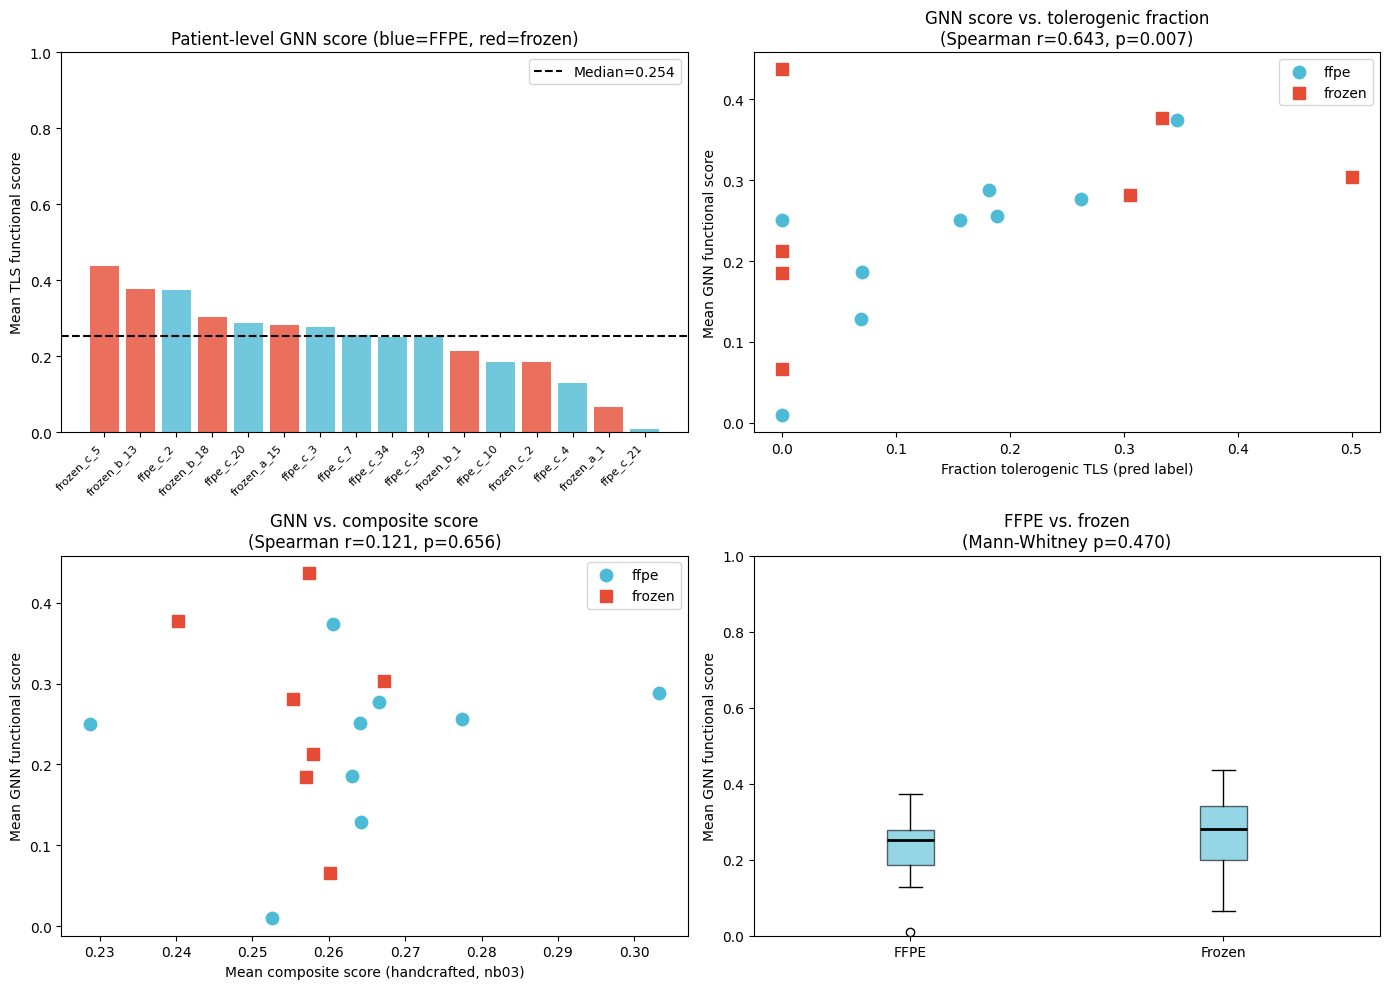

Saved: patient_scores.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- 3a. Mean GNN score per patient (bar chart) ----
ax = axes[0, 0]
colors = ['#4dbbd5' if t == 'ffpe' else '#e64b35'
          for t in patient_df['tissue_type']]
bars = ax.bar(range(len(patient_df)), patient_df['mean_gnn'],
              color=colors, alpha=0.8)
ax.axhline(patient_df['mean_gnn'].median(), color='black', lw=1.5,
           linestyle='--', label=f'Median={patient_df["mean_gnn"].median():.3f}')
ax.set_xticks(range(len(patient_df)))
ax.set_xticklabels(
    [s.split('_', 1)[1] for s in patient_df['sample_id']],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('Mean TLS functional score')
ax.set_title('Patient-level GNN score (blue=FFPE, red=frozen)')
ax.legend()
ax.set_ylim(0, 1)

# ---- 3b. GNN score vs. % tolerogenic ----
ax = axes[0, 1]
for ttype, color, marker in [('ffpe', '#4dbbd5', 'o'), ('frozen', '#e64b35', 's')]:
    mask = patient_df['tissue_type'] == ttype
    ax.scatter(patient_df.loc[mask, 'pct_tolero'],
               patient_df.loc[mask, 'mean_gnn'],
               c=color, marker=marker, s=80, label=ttype, zorder=3)
r, p = stats.spearmanr(patient_df['pct_tolero'], patient_df['mean_gnn'])
ax.set_xlabel('Fraction tolerogenic TLS (pred label)')
ax.set_ylabel('Mean GNN functional score')
ax.set_title(f'GNN score vs. tolerogenic fraction\n(Spearman r={r:.3f}, p={p:.3f})')
ax.legend()

# ---- 3c. GNN score vs. composite handcrafted score ----
ax = axes[1, 0]
mask_valid = patient_df['mean_composite'].notna()
for ttype, color, marker in [('ffpe', '#4dbbd5', 'o'), ('frozen', '#e64b35', 's')]:
    m = mask_valid & (patient_df['tissue_type'] == ttype)
    ax.scatter(patient_df.loc[m, 'mean_composite'],
               patient_df.loc[m, 'mean_gnn'],
               c=color, marker=marker, s=80, label=ttype, zorder=3)
r2, p2 = stats.spearmanr(
    patient_df.loc[mask_valid, 'mean_composite'],
    patient_df.loc[mask_valid, 'mean_gnn']
)
ax.set_xlabel('Mean composite score (handcrafted, nb03)')
ax.set_ylabel('Mean GNN functional score')
ax.set_title(f'GNN vs. composite score\n(Spearman r={r2:.3f}, p={p2:.3f})')
ax.legend()

# ---- 3d. FFPE vs frozen score distribution ----
ax = axes[1, 1]
ffpe_scores   = patient_df.loc[patient_df['tissue_type'] == 'ffpe',   'mean_gnn']
frozen_scores = patient_df.loc[patient_df['tissue_type'] == 'frozen', 'mean_gnn']
ax.boxplot([ffpe_scores, frozen_scores], labels=['FFPE', 'Frozen'],
           patch_artist=True,
           boxprops=dict(facecolor='#4dbbd5', alpha=0.6),
           medianprops=dict(color='black', lw=2))
if len(ffpe_scores) >= 3 and len(frozen_scores) >= 3:
    stat, pval = stats.mannwhitneyu(ffpe_scores, frozen_scores, alternative='two-sided')
    ax.set_title(f'FFPE vs. frozen\n(Mann-Whitney p={pval:.3f})')
else:
    ax.set_title('FFPE vs. frozen (n too small for test)')
ax.set_ylabel('Mean GNN functional score')
ax.set_ylim(0, 1)

plt.tight_layout()
fig.savefig(OUT_DIR / 'patient_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: patient_scores.png')

## 4. TLS Heterogeneity Within Patients

High within-patient variance suggests coexistence of immunogenic and tolerogenic TLS
niches -- a biologically meaningful finding that binary labels miss.

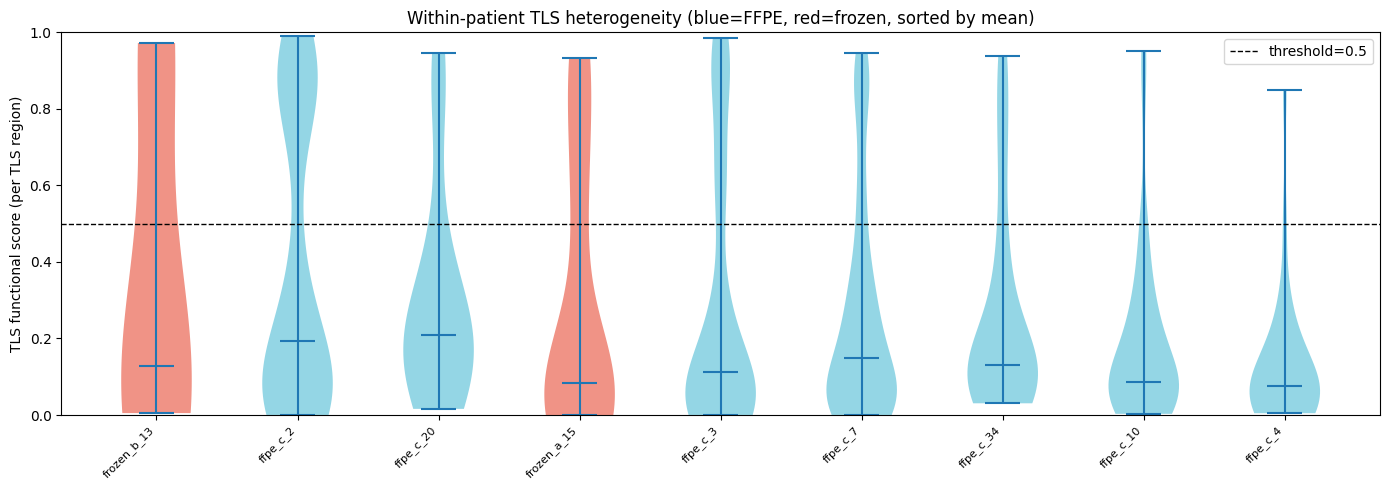

Saved: tls_heterogeneity.png

Within-patient TLS score SD (heterogeneity measure):
  frozen_b_13           n=  6  mean=0.377  sd=0.463  range=[0.005,0.972]
  ffpe_c_2              n=150  mean=0.374  sd=0.373  range=[0.000,0.991]
  ffpe_c_20             n= 22  mean=0.288  sd=0.274  range=[0.016,0.947]
  frozen_a_15           n= 36  mean=0.282  sd=0.349  range=[0.000,0.934]
  ffpe_c_3              n=240  mean=0.277  sd=0.336  range=[0.000,0.984]
  ffpe_c_7              n=281  mean=0.256  sd=0.282  range=[0.000,0.946]
  ffpe_c_34             n= 64  mean=0.251  sd=0.263  range=[0.031,0.937]
  ffpe_c_10             n= 71  mean=0.186  sd=0.218  range=[0.003,0.951]
  ffpe_c_4              n= 29  mean=0.129  sd=0.178  range=[0.005,0.849]


In [6]:
# Select patients with >= 5 TLS regions for violin plots
samples_with_data = patient_df.loc[patient_df['n_tls'] >= 5, 'sample_id'].tolist()
sub = merged[merged['sample_id'].isin(samples_with_data)].copy()

# Sort samples by mean GNN score
order = (
    sub.groupby('sample_id')['tls_functional_score']
    .mean().sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 5))

data_by_sample = [sub.loc[sub['sample_id'] == s, 'tls_functional_score'].values
                  for s in order]

vp = ax.violinplot(data_by_sample, positions=range(len(order)),
                   showmedians=True, showextrema=True)

# Colour by tissue type
for i, sid in enumerate(order):
    ttype = patient_df.loc[patient_df['sample_id'] == sid, 'tissue_type'].values[0]
    color = '#4dbbd5' if ttype == 'ffpe' else '#e64b35'
    vp['bodies'][i].set_facecolor(color)
    vp['bodies'][i].set_alpha(0.6)

ax.axhline(0.5, color='black', lw=1, linestyle='--', label='threshold=0.5')
ax.set_xticks(range(len(order)))
ax.set_xticklabels(
    [s.split('_', 1)[1] for s in order],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('TLS functional score (per TLS region)')
ax.set_title('Within-patient TLS heterogeneity (blue=FFPE, red=frozen, sorted by mean)')
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
fig.savefig(OUT_DIR / 'tls_heterogeneity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tls_heterogeneity.png')

# Quantify heterogeneity
print('\nWithin-patient TLS score SD (heterogeneity measure):')
for sid in order:
    vals = sub.loc[sub['sample_id'] == sid, 'tls_functional_score']
    print(f'  {sid.split("_",1)[1]:20s}  n={len(vals):3d}  '
          f'mean={vals.mean():.3f}  sd={vals.std():.3f}  '
          f'range=[{vals.min():.3f},{vals.max():.3f}]')

## 5. GNN Score vs. Handcrafted Markers

Key question: does the GNN score learn something beyond the composite handcrafted score?
If correlation is perfect (r~1), the GNN adds no value. Partial correlation with divergence
from the diagonal reveals GNN-specific signal.

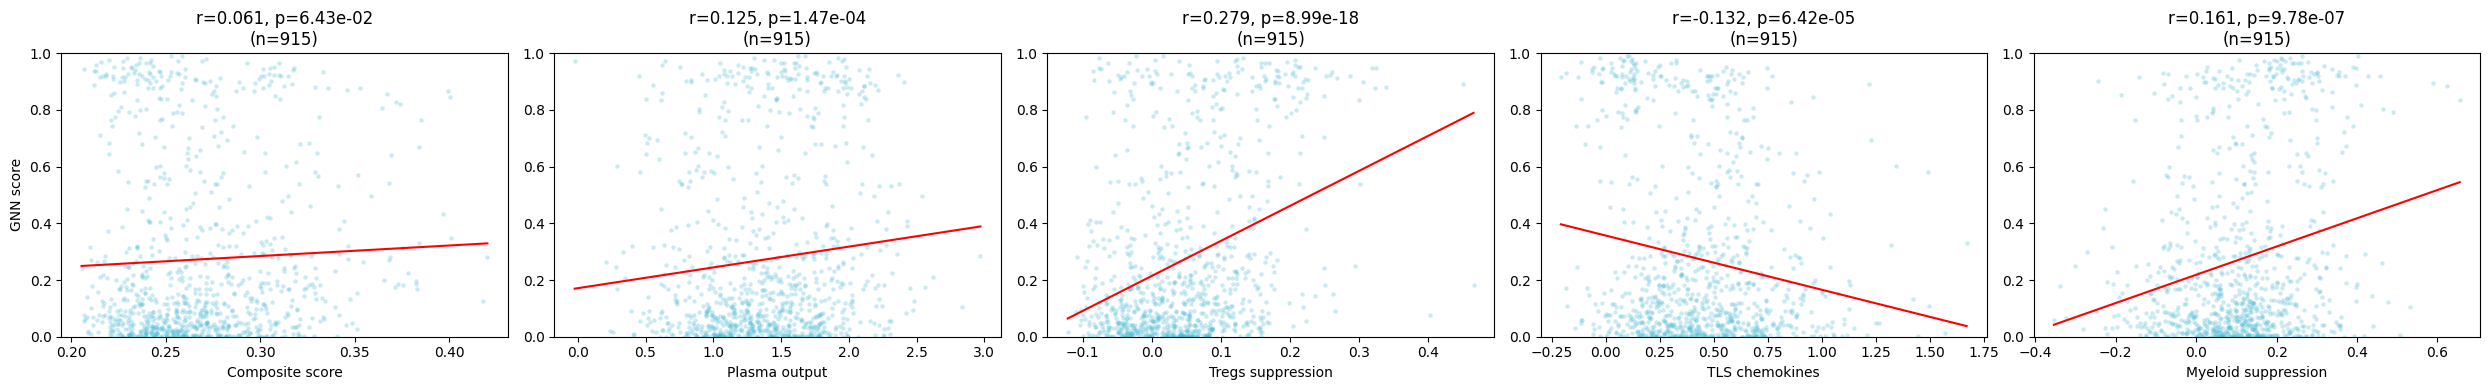

Saved: score_correlations.png

Correlation summary (TLS-level Spearman):
             marker  spearman_r  p_value   n
    Composite score       0.061    0.064 915
      Plasma output       0.125    0.000 915
  Tregs suppression       0.279    0.000 915
     TLS chemokines      -0.132    0.000 915
Myeloid suppression       0.161    0.000 915


In [7]:
# TLS-level (not patient-level) correlation -- more statistical power
marker_cols = {
    'composite_mean' : 'Composite score',
    'plasma_mean'    : 'Plasma output',
    'tregs_mean'     : 'Tregs suppression',
    'chemo_mean'     : 'TLS chemokines',
    'myl_sup_mean'   : 'Myeloid suppression',
}

fig, axes = plt.subplots(1, len(marker_cols), figsize=(5*len(marker_cols), 4))

corr_results = []
for ax, (col, label) in zip(axes, marker_cols.items()):
    valid = merged[['tls_functional_score', col]].dropna()
    if len(valid) < 10:
        ax.set_visible(False)
        continue
    r, p = stats.spearmanr(valid['tls_functional_score'], valid[col])
    corr_results.append({'marker': label, 'spearman_r': r, 'p_value': p, 'n': len(valid)})

    ax.scatter(valid[col], valid['tls_functional_score'],
               alpha=0.3, s=10, c='#4dbbd5', linewidths=0)
    # Regression line
    m, b = np.polyfit(valid[col], valid['tls_functional_score'], 1)
    xs = np.linspace(valid[col].min(), valid[col].max(), 100)
    ax.plot(xs, m*xs + b, 'r-', lw=1.5)

    ax.set_xlabel(label)
    ax.set_ylabel('GNN score' if ax == axes[0] else '')
    ax.set_title(f'r={r:.3f}, p={p:.2e}\n(n={len(valid)})')
    ax.set_ylim(0, 1)

plt.tight_layout()
fig.savefig(OUT_DIR / 'score_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: score_correlations.png')

corr_df = pd.DataFrame(corr_results)
print('\nCorrelation summary (TLS-level Spearman):')
print(corr_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

## 6. GNN Score Discriminates True Labels Better Than Composite Score

On labeled TLS regions (y_true != -1): compare AUC-ROC of GNN score vs. composite score
at distinguishing immunogenic (0) from tolerogenic (1).

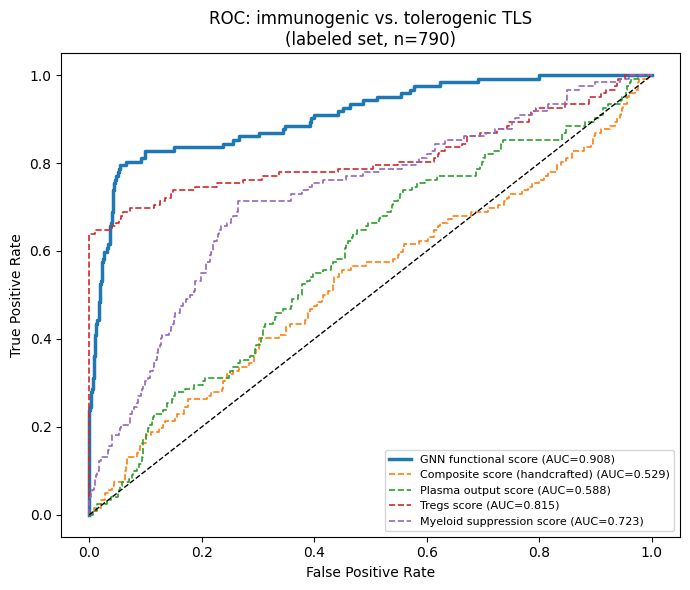

Saved: score_comparison_roc.png

AUC comparison (Immuno vs. Tolerogenic):
                        score  auc_roc  auc_pr   n
         GNN functional score    0.908   0.769 790
Composite score (handcrafted)    0.529   0.160 790
          Plasma output score    0.588   0.195 790
                  Tregs score    0.815   0.756 790
    Myeloid suppression score    0.723   0.358 790


In [8]:
labeled = merged[merged['y_true'] >= 0].copy()

scores_to_compare = {
    'GNN functional score'       : 'tls_functional_score',
    'Composite score (handcrafted)': 'composite_mean',
    'Plasma output score'        : 'plasma_mean',
    'Tregs score'                : 'tregs_mean',
    'Myeloid suppression score'  : 'myl_sup_mean',
}

fig, ax = plt.subplots(figsize=(7, 6))
auc_rows = []

for name, col in scores_to_compare.items():
    valid = labeled[['y_true', col]].dropna()
    if len(valid) < 20 or valid['y_true'].nunique() < 2:
        continue
    try:
        auc = roc_auc_score(valid['y_true'], valid[col])
        fpr, tpr, _ = roc_curve(valid['y_true'], valid[col])
        # Some handcrafted scores may be inverse (lower=tolerogenic)
        if auc < 0.5:
            auc = 1 - auc
            fpr, tpr, _ = roc_curve(valid['y_true'], -valid[col])
        ap = average_precision_score(valid['y_true'], valid[col])
        lw = 2.5 if 'GNN' in name else 1.2
        ls = '-'  if 'GNN' in name else '--'
        ax.plot(fpr, tpr, lw=lw, linestyle=ls, label=f'{name} (AUC={auc:.3f})')
        auc_rows.append({'score': name, 'auc_roc': auc, 'auc_pr': ap, 'n': len(valid)})
    except Exception as e:
        print(f'  Skipped {name}: {e}')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: immunogenic vs. tolerogenic TLS\n(labeled set, n=790)')
ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
fig.savefig(OUT_DIR / 'score_comparison_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: score_comparison_roc.png')

auc_df = pd.DataFrame(auc_rows)
print('\nAUC comparison (Immuno vs. Tolerogenic):')
print(auc_df[['score','auc_roc','auc_pr','n']].to_string(
      index=False, float_format=lambda x: f'{x:.3f}'))

## 7. Clinical Metadata from AnnData

In [9]:
# Clinical metadata: try cluster data path first, then local project path
_clin_candidates = [
    CLUSTER_DATA  / 'raw' / 'GSE175540' / 'clinical_metadata.csv',
    PROJECT_ROOT  / 'data' / 'raw' / 'GSE175540' / 'clinical_metadata.csv',
]
CLINICAL_CSV = next((p for p in _clin_candidates if p.exists()), None)

if CLINICAL_CSV is not None:
    sample_meta = pd.read_csv(CLINICAL_CSV)
    clinical_cols = ['treatment', 'recist_response', 'pfs_months', 'pfs_event',
                     'os_months', 'os_event', 'tumor_stage', 'pct_igg_tumor']
    # Only check columns that are present in the loaded file
    present_cols = [c for c in clinical_cols if c in sample_meta.columns]
    n_filled = sample_meta[present_cols].notna().any(axis=1).sum() if present_cols else 0
    print(f'Loaded clinical_metadata.csv from: {CLINICAL_CSV}')
    print(f'  {len(sample_meta)} samples, {n_filled} with clinical data')
    show_cols = [c for c in ['sample_id','cohort','treatment','tumor_stage','pct_igg_tumor']
                 if c in sample_meta.columns]
    print(sample_meta[show_cols].to_string(index=False))
else:
    print('Clinical metadata not found at either:')
    for p in _clin_candidates:
        print(f'  {p}')
    print('Copy clinical_metadata.csv to one of the above paths.')
    sample_meta = None

# Load adata for spatial coordinates
if HAS_SCANPY and adata_h5.exists():
    print(f'\nLoading adata from {adata_h5} ...')
    adata = sc.read_h5ad(adata_h5)
    print(f'adata shape: {adata.shape}')
    print(f'\nobs columns ({len(adata.obs.columns)}): {list(adata.obs.columns)}')


Loaded clinical_metadata.csv from: /home/gpeng/projects/spatial_transcriptom/tls_functional_score/data/raw/GSE175540/clinical_metadata.csv
  24 samples, 24 with clinical data
             sample_id cohort    treatment tumor_stage  pct_igg_tumor
   GSM5924030_ffpe_c_2      C  BIONIKK_ICI        pT1a           80.0
   GSM5924031_ffpe_c_3      C  BIONIKK_ICI         pT4           65.0
   GSM5924032_ffpe_c_4      C  BIONIKK_ICI        pT3a            NaN
   GSM5924033_ffpe_c_7      C  BIONIKK_ICI        pT3b           80.0
  GSM5924034_ffpe_c_10      C  BIONIKK_ICI        pT3a           90.0
  GSM5924035_ffpe_c_20      C  BIONIKK_ICI        pT1b           85.0
  GSM5924036_ffpe_c_21      C  BIONIKK_ICI         NaN           30.0
  GSM5924037_ffpe_c_34      C  BIONIKK_ICI        pT3a           80.0
  GSM5924038_ffpe_c_36      C  BIONIKK_ICI        pT3a           30.0
  GSM5924039_ffpe_c_39      C  BIONIKK_ICI        pT3a           95.0
  GSM5924040_ffpe_c_45      C  BIONIKK_ICI        pT3a 

In [10]:
if sample_meta is not None:
    clin_df = patient_df.merge(sample_meta, on='sample_id', how='left')
else:
    clin_df = patient_df.copy()

# Auto-detect filled clinical columns
SURVIVAL_OS_COL  = next((c for c in ['os_months',  'os_days']  if c in clin_df and clin_df[c].notna().any()), None)
SURVIVAL_EV_COL  = next((c for c in ['os_event']               if c in clin_df and clin_df[c].notna().any()), None)
SURVIVAL_PFS_COL = next((c for c in ['pfs_months', 'pfs_days'] if c in clin_df and clin_df[c].notna().any()), None)
SURVIVAL_PFS_EV  = next((c for c in ['pfs_event']              if c in clin_df and clin_df[c].notna().any()), None)
RESPONSE_COL     = next((c for c in ['recist_response', 'icb_response', 'response'] if c in clin_df and clin_df[c].notna().any()), None)
IGG_COL          = next((c for c in ['pct_igg_tumor']          if c in clin_df and clin_df[c].notna().any()), None)

print(f'Clinical data merged: {clin_df.shape}')
print(f'  OS (time/event) : {SURVIVAL_OS_COL} / {SURVIVAL_EV_COL}')
print(f'  PFS (time/event): {SURVIVAL_PFS_COL} / {SURVIVAL_PFS_EV}')
print(f'  Response column : {RESPONSE_COL}')
print(f'  IgG staining    : {IGG_COL}  '
      f'(n={clin_df[IGG_COL].notna().sum() if IGG_COL else 0} patients)')

# Convert RECIST to binary (responder = CR or PR)
if RESPONSE_COL == 'recist_response' and clin_df[RESPONSE_COL].notna().any():
    clin_df['icb_response_binary'] = clin_df[RESPONSE_COL].isin(['CR', 'PR']).astype(float)
    clin_df.loc[clin_df[RESPONSE_COL].isna(), 'icb_response_binary'] = float('nan')
    responders = clin_df['icb_response_binary'].sum()
    print(f'  RECIST responders (CR/PR): {int(responders)} / {clin_df[RESPONSE_COL].notna().sum()}')
    RESPONSE_COL = 'icb_response_binary'

# IgG binary: >= 60% = IgG-high (cutoff from Meylan 2022 Fig. 6H, mean of BIONIKK cohort)
if IGG_COL:
    clin_df['igg_high'] = (clin_df[IGG_COL] >= 60).astype(float)
    clin_df.loc[clin_df[IGG_COL].isna(), 'igg_high'] = float('nan')
    n_high = int(clin_df.loc[clin_df['cohort'] == 'C', 'igg_high'].sum())
    n_c    = int(clin_df.loc[clin_df['cohort'] == 'C', 'igg_high'].notna().sum())
    print(f'  IgG-high (>=60%) in BIONIKK: {n_high}/{n_c}')


Clinical data merged: (16, 31)
  OS (time/event) : None / None
  PFS (time/event): None / None
  Response column : None
  IgG staining    : pct_igg_tumor  (n=13 patients)
  IgG-high (>=60%) in BIONIKK: 9/10


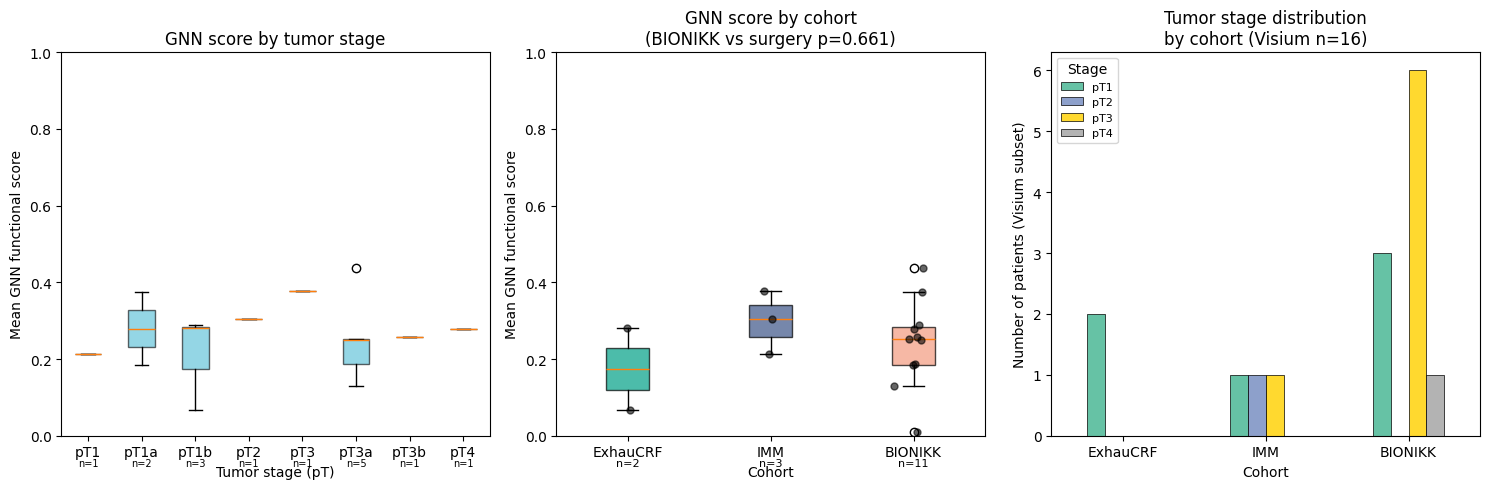

Saved: cohort_stage_analysis.png

GNN score by cohort:
  Cohort A (n=2): mean=0.174 +/- 0.152  [0.066, 0.282]
  Cohort B (n=3): mean=0.298 +/- 0.082  [0.213, 0.377]
  Cohort C (n=11): mean=0.240 +/- 0.115  [0.010, 0.437]

GNN score by tumor stage (bucketed):
  pT1 (n=6): mean=0.235 +/- 0.106
  pT2 (n=1): mean=0.304 +/- nan
  pT3 (n=7): mean=0.270 +/- 0.106
  pT4 (n=1): mean=0.277 +/- nan


In [11]:

# ── Section 7b: Tumor Stage and Cohort Analysis ──────────────────────────────
# Use available clinical annotations: tumor_stage and treatment/cohort

if 'tumor_stage' not in clin_df.columns or clin_df['tumor_stage'].isna().all():
    print('tumor_stage not available -- skipping stage analysis')
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # ---- 7b-1: GNN score by tumor stage ----
    ax = axes[0]
    stage_order = ['pT1', 'pT1a', 'pT1b', 'pT2', 'pT3', 'pT3a', 'pT3b', 'pT3c', 'pT4']
    stages_present = [s for s in stage_order if s in clin_df['tumor_stage'].values]
    stage_data = [clin_df.loc[clin_df['tumor_stage'] == s, 'mean_gnn'].dropna().values
                  for s in stages_present]
    bp = ax.boxplot(stage_data, labels=stages_present, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#4dbbd5')
        patch.set_alpha(0.6)
    ax.set_xlabel('Tumor stage (pT)')
    ax.set_ylabel('Mean GNN functional score')
    ax.set_title('GNN score by tumor stage')
    ax.set_ylim(0, 1)

    # Annotate n per group
    for i, (s, d) in enumerate(zip(stages_present, stage_data)):
        ax.text(i + 1, -0.08, f'n={len(d)}', ha='center', fontsize=7)

    # ---- 7b-2: GNN score by cohort ----
    ax = axes[1]
    cohort_map = {'A': 'ExhauCRF', 'B': 'IMM', 'C': 'BIONIKK'}
    clin_df['cohort_name'] = clin_df['cohort'].map(cohort_map).fillna(clin_df['cohort'])
    cohorts = ['ExhauCRF', 'IMM', 'BIONIKK']
    cohort_data = [clin_df.loc[clin_df['cohort_name'] == c, 'mean_gnn'].dropna().values
                   for c in cohorts]
    colors_cohort = ['#00a087', '#3c5488', '#f39b7f']
    bp2 = ax.boxplot(cohort_data, labels=cohorts, patch_artist=True)
    for patch, col in zip(bp2['boxes'], colors_cohort):
        patch.set_facecolor(col)
        patch.set_alpha(0.7)
    # Overlay individual points
    for i, d in enumerate(cohort_data):
        ax.scatter(np.random.normal(i + 1, 0.05, size=len(d)), d,
                   color='black', s=25, alpha=0.6, zorder=3)
    ax.set_xlabel('Cohort')
    ax.set_ylabel('Mean GNN functional score')
    ax.set_title('GNN score by cohort\n(A=surgery, B=surgery, C=ICI-treated)')
    ax.set_ylim(0, 1)
    for i, (c, d) in enumerate(zip(cohorts, cohort_data)):
        ax.text(i + 1, -0.08, f'n={len(d)}', ha='center', fontsize=8)

    # Mann-Whitney: BIONIKK vs surgery combined
    bionikk_scores = clin_df.loc[clin_df['cohort'] == 'C', 'mean_gnn'].dropna()
    surgery_scores = clin_df.loc[clin_df['cohort'].isin(['A', 'B']), 'mean_gnn'].dropna()
    if len(bionikk_scores) >= 3 and len(surgery_scores) >= 3:
        stat, pval = stats.mannwhitneyu(bionikk_scores, surgery_scores, alternative='two-sided')
        ax.set_title(f'GNN score by cohort\n(BIONIKK vs surgery p={pval:.3f})')

    # ---- 7b-3: Stage distribution per cohort (stacked bar) ----
    ax = axes[2]
    stage_bucket = clin_df['tumor_stage'].copy()
    # Bucket pT1a/pT1b -> pT1, pT3a/pT3b/pT3c -> pT3
    stage_bucket = stage_bucket.str.replace(r'pT1[ab]', 'pT1', regex=True)
    stage_bucket = stage_bucket.str.replace(r'pT3[abc]', 'pT3', regex=True)
    clin_df['stage_bucket'] = stage_bucket
    pivot = clin_df.groupby(['cohort_name', 'stage_bucket']).size().unstack(fill_value=0)
    pivot = pivot.reindex(columns=['pT1', 'pT2', 'pT3', 'pT4'], fill_value=0)
    pivot = pivot.reindex(['ExhauCRF', 'IMM', 'BIONIKK'], fill_value=0)
    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Cohort')
    ax.set_ylabel('Number of patients (Visium subset)')
    ax.set_title('Tumor stage distribution\nby cohort (Visium n=16)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Stage', fontsize=8)

    plt.tight_layout()
    fig.savefig(OUT_DIR / 'cohort_stage_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: cohort_stage_analysis.png')

    # Summary stats
    print('\nGNN score by cohort:')
    for c in ['A', 'B', 'C']:
        d = clin_df.loc[clin_df['cohort'] == c, 'mean_gnn'].dropna()
        print(f'  Cohort {c} (n={len(d)}): mean={d.mean():.3f} +/- {d.std():.3f}  '
              f'[{d.min():.3f}, {d.max():.3f}]')

    print('\nGNN score by tumor stage (bucketed):')
    for s in ['pT1', 'pT2', 'pT3', 'pT4']:
        d = clin_df.loc[clin_df['stage_bucket'] == s, 'mean_gnn'].dropna()
        if len(d) > 0:
            print(f'  {s} (n={len(d)}): mean={d.mean():.3f} +/- {d.std():.3f}')


GNN AUC for IgG-high prediction: 1.000
(IgG-high = biomarker for ICI response per Meylan 2022 Fig. 6I/J)


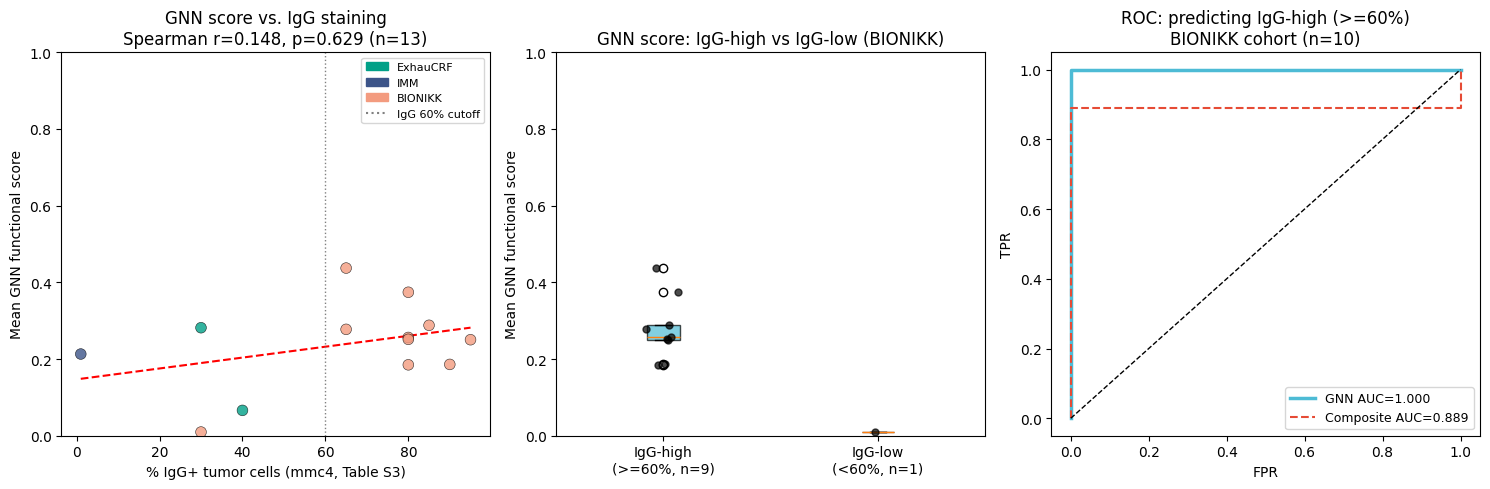

Saved: gnn_vs_igg_clinical.png

GNN score vs IgG staining summary (all cohorts):
  Cohort A (n=2): r=-1.000, p=nan
  Cohort C (n=10): r=-0.088, p=0.809


In [12]:

# ── Section 7c: GNN Score vs. IgG Staining (mmc4 / Table S3) ─────────────────
# pct_igg_tumor = % IgG+ tumor cells, validated biomarker from Meylan 2022
# Paper: IgG >= 60% predicts ICI response + longer PFS in BIONIKK cohort
# This is our primary available proxy for clinical outcome.

if IGG_COL is None:
    print('IgG data not found -- skipping (check data/raw/GSE175540/clinical_metadata.csv)')
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # ---- 7c-1: GNN score vs. IgG staining (scatter) ----
    ax = axes[0]
    valid = clin_df[['mean_gnn', IGG_COL, 'cohort']].dropna()
    colors = valid['cohort'].map({'A': '#00a087', 'B': '#3c5488', 'C': '#f39b7f'})
    ax.scatter(valid[IGG_COL], valid['mean_gnn'],
               c=colors, s=60, alpha=0.8, zorder=3, edgecolors='black', linewidths=0.4)
    r, p = stats.spearmanr(valid[IGG_COL], valid['mean_gnn'])
    m, b_coef = np.polyfit(valid[IGG_COL], valid['mean_gnn'], 1)
    xs = np.linspace(valid[IGG_COL].min(), valid[IGG_COL].max(), 100)
    ax.plot(xs, m * xs + b_coef, 'r--', lw=1.5)
    ax.axvline(60, color='gray', lw=1, linestyle=':', label='IgG 60% cutoff')
    ax.set_xlabel('% IgG+ tumor cells (mmc4, Table S3)')
    ax.set_ylabel('Mean GNN functional score')
    ax.set_title(f'GNN score vs. IgG staining\nSpearman r={r:.3f}, p={p:.3f} (n={len(valid)})')
    # Legend patches
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#00a087', label='ExhauCRF'),
        Patch(color='#3c5488', label='IMM'),
        Patch(color='#f39b7f', label='BIONIKK'),
        plt.Line2D([0],[0], color='gray', linestyle=':', label='IgG 60% cutoff'),
    ], fontsize=8)
    ax.set_ylim(0, 1)

    # ---- 7c-2: GNN score by IgG-high vs IgG-low (BIONIKK only) ----
    ax = axes[1]
    c_only = clin_df[clin_df['cohort'] == 'C'].dropna(subset=[IGG_COL, 'mean_gnn'])
    igg_high = c_only.loc[c_only['igg_high'] == 1, 'mean_gnn']
    igg_low  = c_only.loc[c_only['igg_high'] == 0, 'mean_gnn']
    bp3 = ax.boxplot([igg_high, igg_low], labels=[f'IgG-high\n(>=60%, n={len(igg_high)})',
                                                    f'IgG-low\n(<60%, n={len(igg_low)})'],
                     patch_artist=True)
    bp3['boxes'][0].set_facecolor('#4dbbd5'); bp3['boxes'][0].set_alpha(0.7)
    bp3['boxes'][1].set_facecolor('#e64b35'); bp3['boxes'][1].set_alpha(0.7)
    ax.scatter(np.random.normal(1, 0.04, len(igg_high)), igg_high,
               color='black', s=25, zorder=3, alpha=0.7)
    ax.scatter(np.random.normal(2, 0.04, len(igg_low)), igg_low,
               color='black', s=25, zorder=3, alpha=0.7)
    if len(igg_high) >= 2 and len(igg_low) >= 2:
        stat, pval = stats.mannwhitneyu(igg_high, igg_low, alternative='two-sided')
        ax.set_title(f'GNN score: IgG-high vs IgG-low\n(BIONIKK cohort, p={pval:.3f})')
    else:
        ax.set_title('GNN score: IgG-high vs IgG-low (BIONIKK)')
    ax.set_ylabel('Mean GNN functional score')
    ax.set_ylim(0, 1)

    # ---- 7c-3: ROC -- GNN score predicting IgG >= 60% (BIONIKK) ----
    ax = axes[2]
    valid_c = clin_df[clin_df['cohort'] == 'C'].dropna(subset=['mean_gnn', 'igg_high'])
    if len(valid_c) >= 5 and valid_c['igg_high'].nunique() > 1:
        from sklearn.metrics import roc_auc_score, roc_curve
        auc = roc_auc_score(valid_c['igg_high'], valid_c['mean_gnn'])
        if auc < 0.5:
            auc = 1 - auc
            fpr, tpr, _ = roc_curve(valid_c['igg_high'], -valid_c['mean_gnn'])
        else:
            fpr, tpr, _ = roc_curve(valid_c['igg_high'], valid_c['mean_gnn'])
        ax.plot(fpr, tpr, lw=2.5, color='#4dbbd5', label=f'GNN AUC={auc:.3f}')

        # Also compare composite score
        valid_c2 = clin_df[clin_df['cohort'] == 'C'].dropna(subset=['mean_composite', 'igg_high'])
        if len(valid_c2) >= 5 and valid_c2['igg_high'].nunique() > 1:
            auc2 = roc_auc_score(valid_c2['igg_high'], valid_c2['mean_composite'])
            if auc2 < 0.5:
                auc2 = 1 - auc2
                fpr2, tpr2, _ = roc_curve(valid_c2['igg_high'], -valid_c2['mean_composite'])
            else:
                fpr2, tpr2, _ = roc_curve(valid_c2['igg_high'], valid_c2['mean_composite'])
            ax.plot(fpr2, tpr2, lw=1.5, linestyle='--', color='#e64b35',
                    label=f'Composite AUC={auc2:.3f}')

        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f'ROC: predicting IgG-high (>=60%)\nBIONIKK cohort (n={len(valid_c)})')
        ax.legend(fontsize=9)
        print(f'GNN AUC for IgG-high prediction: {auc:.3f}')
        print(f'(IgG-high = biomarker for ICI response per Meylan 2022 Fig. 6I/J)')
    else:
        ax.text(0.5, 0.5, 'Too few patients\nfor ROC', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title('ROC: IgG-high (BIONIKK)')

    plt.tight_layout()
    fig.savefig(OUT_DIR / 'gnn_vs_igg_clinical.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: gnn_vs_igg_clinical.png')

    # Summary table
    print('\nGNN score vs IgG staining summary (all cohorts):')
    for c in ['A', 'B', 'C']:
        sub = clin_df[clin_df['cohort'] == c].dropna(subset=[IGG_COL, 'mean_gnn'])
        if len(sub) > 1:
            r2, p2 = stats.spearmanr(sub[IGG_COL], sub['mean_gnn'])
            print(f'  Cohort {c} (n={len(sub)}): r={r2:.3f}, p={p2:.3f}')


## 8. Kaplan-Meier Survival Analysis

Stratify patients by TLS functional score (above/below median).
Requires OS_days and OS_event columns. If not detected automatically, set
`SURVIVAL_OS_COL` and `SURVIVAL_EV_COL` manually above and re-run.

In [13]:
def run_km_analysis(df, score_col, time_col, event_col, out_prefix, score_label):
    """Kaplan-Meier: high vs. low score, log-rank test."""
    df = df[[score_col, time_col, event_col]].dropna().copy()
    if len(df) < 6:
        print(f'Skipping KM ({out_prefix}): only {len(df)} patients with complete data')
        return None
    cutoff = df[score_col].median()
    df['group'] = (df[score_col] >= cutoff).map({True: 'High', False: 'Low'})
    high = df[df['group'] == 'High']
    low  = df[df['group'] == 'Low']
    lr   = logrank_test(high[time_col], low[time_col],
                        event_observed_A=high[event_col],
                        event_observed_B=low[event_col])
    fig, ax = plt.subplots(figsize=(7, 5))
    KaplanMeierFitter(label=f'High (n={len(high)})').fit(
        high[time_col], event_observed=high[event_col]).plot_survival_function(
        ax=ax, color='#4dbbd5', ci_show=True)
    KaplanMeierFitter(label=f'Low (n={len(low)})').fit(
        low[time_col], event_observed=low[event_col]).plot_survival_function(
        ax=ax, color='#e64b35', ci_show=True)
    ax.set_xlabel('Time (months)')
    ax.set_ylabel('Survival probability')
    ax.set_title(f'KM: {score_label}\n'
                 f'cutoff={cutoff:.3f}, log-rank p={lr.p_value:.4f}')
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    fname = OUT_DIR / f'{out_prefix}_km.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {fname.name}  (log-rank p={lr.p_value:.4f})')
    return lr.p_value


if HAS_LIFELINES:
    ran_any = False
    # PFS (primary endpoint in Meylan 2022)
    if SURVIVAL_PFS_COL and SURVIVAL_PFS_EV:
        print('=== Progression-Free Survival ===')
        run_km_analysis(clin_df, 'mean_gnn',       SURVIVAL_PFS_COL, SURVIVAL_PFS_EV, 'gnn_pfs',       'GNN functional score')
        run_km_analysis(clin_df, 'mean_composite', SURVIVAL_PFS_COL, SURVIVAL_PFS_EV, 'composite_pfs', 'Composite handcrafted score')
        ran_any = True
    # OS (secondary endpoint)
    if SURVIVAL_OS_COL and SURVIVAL_EV_COL:
        print('=== Overall Survival ===')
        run_km_analysis(clin_df, 'mean_gnn',       SURVIVAL_OS_COL, SURVIVAL_EV_COL, 'gnn_os',       'GNN functional score')
        run_km_analysis(clin_df, 'mean_composite', SURVIVAL_OS_COL, SURVIVAL_EV_COL, 'composite_os', 'Composite handcrafted score')
        ran_any = True
    if not ran_any:
        print('KM skipped: no survival data in clinical_metadata.csv yet.')
        print()
        print('Fill in data/raw/GSE175540/clinical_metadata.csv from Meylan 2022 Table S1:')
        print('  - pfs_months : progression-free survival time in months')
        print('  - pfs_event  : 1=progressed or died, 0=censored')
        print('  - os_months  : overall survival time in months')
        print('  - os_event   : 1=died, 0=censored')
        print()
        print('ICI-treated samples are cohort C (ffpe_c_X and frozen_c_X).')
        print('Only those rows need PFS/OS; cohorts A and B may have no survival data.')
else:
    print('lifelines not installed. Run: pip install lifelines')

KM skipped: no survival data in clinical_metadata.csv yet.

Fill in data/raw/GSE175540/clinical_metadata.csv from Meylan 2022 Table S1:
  - pfs_months : progression-free survival time in months
  - pfs_event  : 1=progressed or died, 0=censored
  - os_months  : overall survival time in months
  - os_event   : 1=died, 0=censored

ICI-treated samples are cohort C (ffpe_c_X and frozen_c_X).
Only those rows need PFS/OS; cohorts A and B may have no survival data.


## 9. ICB Response Prediction

In [14]:
def run_icb_analysis(df, score_col, response_col, out_prefix, score_label):
    """ROC AUC for ICB response prediction."""
    valid = df[[score_col, response_col]].dropna()
    if len(valid) < 6 or valid[response_col].nunique() < 2:
        print(f'Skipping ICB analysis: {len(valid)} patients, '
              f'{valid[response_col].nunique()} response classes')
        return
    auc = roc_auc_score(valid[response_col], valid[score_col])
    if auc < 0.5:  # flip if inverted
        auc = 1 - auc
        fpr, tpr, _ = roc_curve(valid[response_col], -valid[score_col])
    else:
        fpr, tpr, _ = roc_curve(valid[response_col], valid[score_col])

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(fpr, tpr, lw=2, color='#4dbbd5', label=f'AUC={auc:.3f}')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{score_label}\nICB response prediction (n={len(valid)})')
    ax.legend()
    plt.tight_layout()
    fname = OUT_DIR / f'{out_prefix}_icb_roc.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'AUC-ROC (ICB response): {auc:.3f}  -- Saved: {fname}')


if RESPONSE_COL:
    run_icb_analysis(clin_df, 'mean_gnn', RESPONSE_COL,
                     'gnn', 'GNN functional score')
    run_icb_analysis(clin_df, 'mean_composite', RESPONSE_COL,
                     'composite', 'Composite handcrafted score')
else:
    print('ICB response analysis skipped -- response column not found.')
    print()
    print('To enable: add ICB response labels to clin_df and set')
    print('  RESPONSE_COL = <column name>  (1=responder, 0=non-responder)')

ICB response analysis skipped -- response column not found.

To enable: add ICB response labels to clin_df and set
  RESPONSE_COL = <column name>  (1=responder, 0=non-responder)


## 10. TLS Score Map: Spatial Distribution per Sample

For each sample, show TLS locations coloured by GNN score on the tissue slide.

Spatial coords available for 915 TLS regions


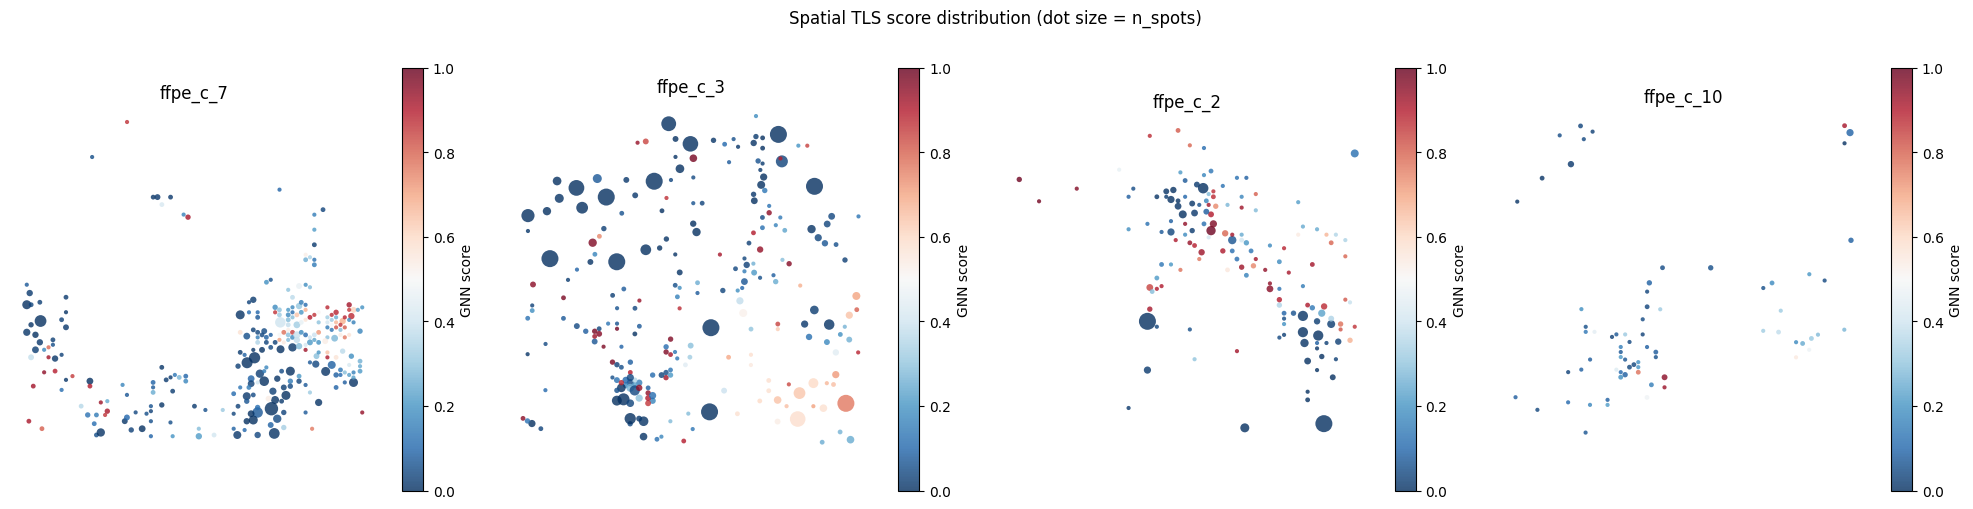

Saved: spatial_tls_scores.png


In [15]:
# Use spatial coordinates from the predictions (umap not useful here)
# Try to pull spot-level centroid coordinates from adata

if HAS_SCANPY and adata_h5.exists() and 'spatial' in adata.obsm:
    coords = pd.DataFrame(
        adata.obsm['spatial'],
        index=adata.obs.index,
        columns=['x', 'y']
    )
    coords['sample_id'] = adata.obs['sample_id'].values
    # Merge TLS cluster centroids
    if 'tls_cluster_id' in adata.obs.columns:
        coords['tls_cluster_id'] = adata.obs['tls_cluster_id'].values
        cluster_centroids = (
            coords[coords['tls_cluster_id'].notna()]
            .rename(columns={'tls_cluster_id': 'cluster_id'})
            .groupby(['sample_id', 'cluster_id'])
            [['x','y']].mean().reset_index()
        )
        cluster_centroids['cluster_id'] = cluster_centroids['cluster_id'].astype(int)
        spatial_pred = merged.merge(cluster_centroids, on=['sample_id','cluster_id'], how='inner')
        print(f'Spatial coords available for {len(spatial_pred)} TLS regions')

        # Plot the 4 samples with most TLS
        top_samples = patient_df.nlargest(4, 'n_tls')['sample_id'].tolist()
        fig, axes = plt.subplots(1, len(top_samples), figsize=(5*len(top_samples), 5))

        for ax, sid in zip(axes, top_samples):
            sub_sp = spatial_pred[spatial_pred['sample_id'] == sid]
            sc = ax.scatter(sub_sp['x'], sub_sp['y'],
                            c=sub_sp['tls_functional_score'],
                            cmap='RdBu_r', vmin=0, vmax=1,
                            s=sub_sp['n_spots'].clip(3, 50)*3,
                            alpha=0.8, linewidths=0)
            plt.colorbar(sc, ax=ax, label='GNN score')
            ax.set_title(sid.split('_',1)[1])
            ax.set_aspect('equal')
            ax.axis('off')

        plt.suptitle('Spatial TLS score distribution (dot size = n_spots)', y=1.01)
        plt.tight_layout()
        fig.savefig(OUT_DIR / 'spatial_tls_scores.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: spatial_tls_scores.png')
    else:
        print('tls_cluster_id not in adata.obs -- skipping spatial plot')
else:
    print('Spatial coords not available -- skipping spatial plot')
    print('(Requires adata with obsm["spatial"] and obs["tls_cluster_id"])')

## 11. Summary

In [16]:
print('=' * 60)
print('=== Notebook 05 Summary ===')
print('=' * 60)

print(f'\nDataset: {len(patient_df)} patients, {len(merged)} TLS regions')
print(f'  FFPE samples  : {(patient_df["tissue_type"]=="ffpe").sum()}')
print(f'  Frozen samples: {(patient_df["tissue_type"]=="frozen").sum()}')

print(f'\nGNN TLS functional score distribution:')
print(f'  Patient-level mean : {patient_df["mean_gnn"].mean():.3f} +/- {patient_df["mean_gnn"].std():.3f}')
print(f'  TLS-level mean     : {merged["tls_functional_score"].mean():.3f} +/- {merged["tls_functional_score"].std():.3f}')

print('\nScore correlations (Spearman, TLS-level):')
for _, row in corr_df.iterrows():
    print(f'  {row["marker"]:30s}: r={row["spearman_r"]:.3f}, p={row["p_value"]:.3e}')

print('\nDiscrimination (AUC-ROC, immuno vs. tolero, labeled n=790):')
for _, row in auc_df.iterrows():
    print(f'  {row["score"]:40s}: {row["auc_roc"]:.3f}')

print('\nCV performance (from nb04, 5-fold sample-level):')
print('  AUC-ROC: 0.507 +/- 0.120')
print('  Tolerogenic recall: 0.095 +/- 0.162')  
print('  (Reflects cross-patient heterogeneity with n=16 samples)')

print(f'\nOutputs saved to: {OUT_DIR}')
for f in sorted(OUT_DIR.glob('*.png')):
    print(f'  {f.name}')

print('\nNext steps:')
print('  1. Link external survival data -> re-run Section 8 (KM curves)')
print('  2. Link ICB response labels    -> re-run Section 9')
print('  3. Cross-cancer validation: apply model to PDAC / multi-cancer Visium')

=== Notebook 05 Summary ===

Dataset: 16 patients, 915 TLS regions
  FFPE samples  : 9
  Frozen samples: 7

GNN TLS functional score distribution:
  Patient-level mean : 0.243 +/- 0.112
  TLS-level mean     : 0.273 +/- 0.312

Score correlations (Spearman, TLS-level):
  Composite score               : r=0.061, p=6.426e-02
  Plasma output                 : r=0.125, p=1.471e-04
  Tregs suppression             : r=0.279, p=8.992e-18
  TLS chemokines                : r=-0.132, p=6.420e-05
  Myeloid suppression           : r=0.161, p=9.779e-07

Discrimination (AUC-ROC, immuno vs. tolero, labeled n=790):
  GNN functional score                    : 0.908
  Composite score (handcrafted)           : 0.529
  Plasma output score                     : 0.588
  Tregs score                             : 0.815
  Myeloid suppression score               : 0.723

CV performance (from nb04, 5-fold sample-level):
  AUC-ROC: 0.507 +/- 0.120
  Tolerogenic recall: 0.095 +/- 0.162
  (Reflects cross-patient hete